In [3]:
import pandas as pd
import sqlite3 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [6]:
# Creating connection
conn = sqlite3.connect('inventory.db')
df = pd.read_sql_query('Select * from vendor_sales_summary',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
 - Previously, we examined various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

 - In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.   

In [6]:
# summary satatistics 
df.describe().T #for trnaspose

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


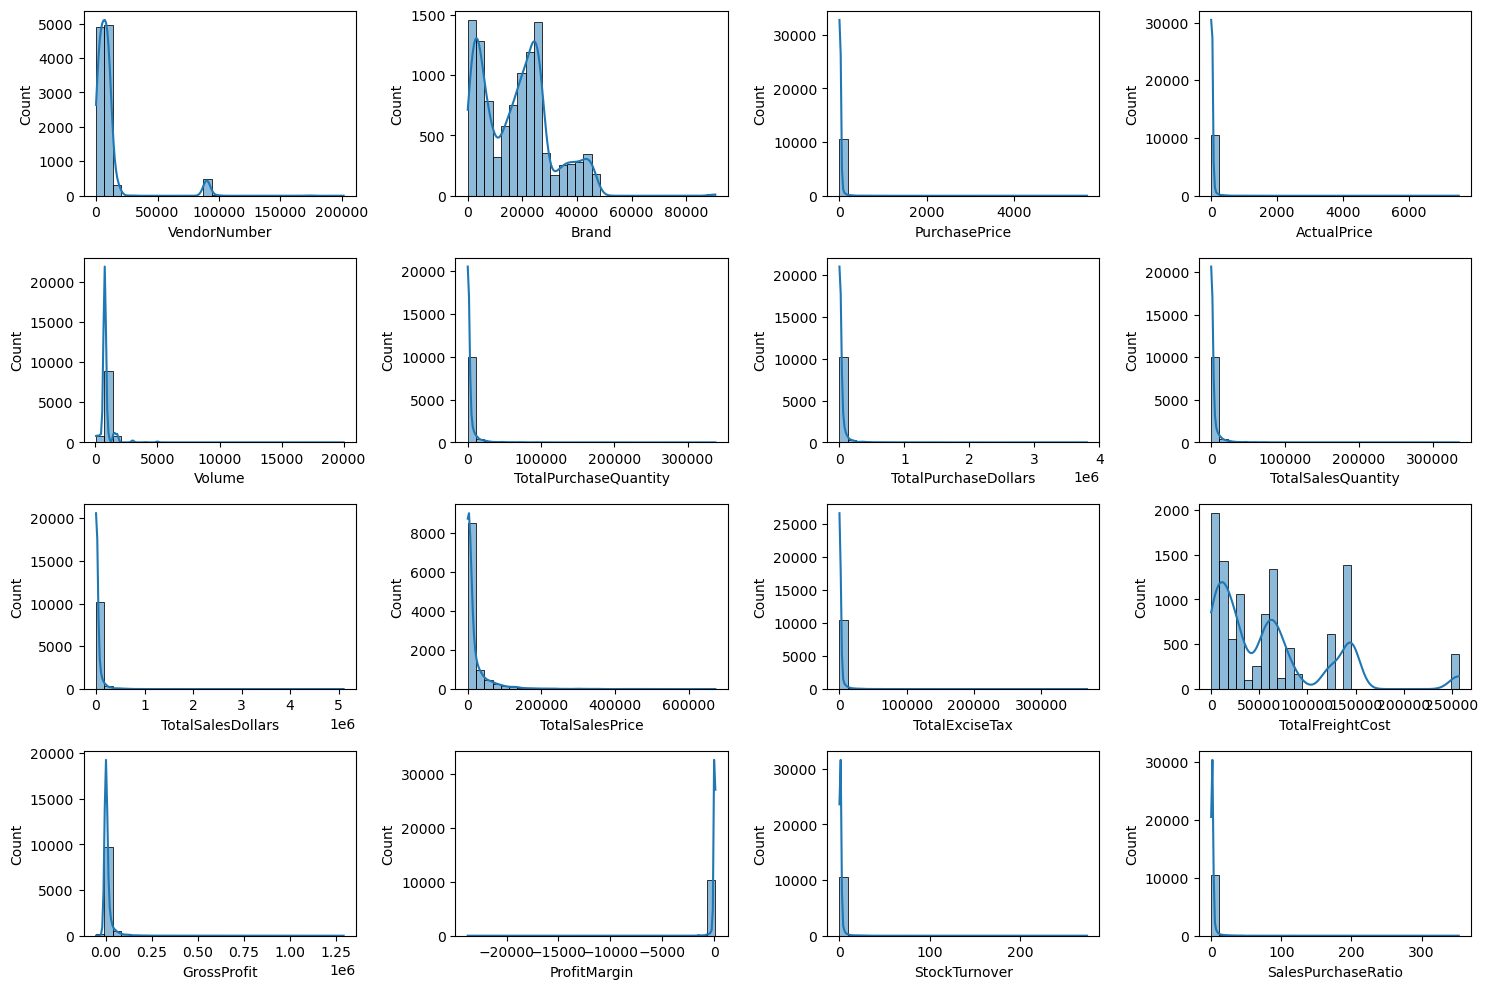

In [9]:
#Ditribution plots for numerical columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
plt.tight_layout()
plt.show()    

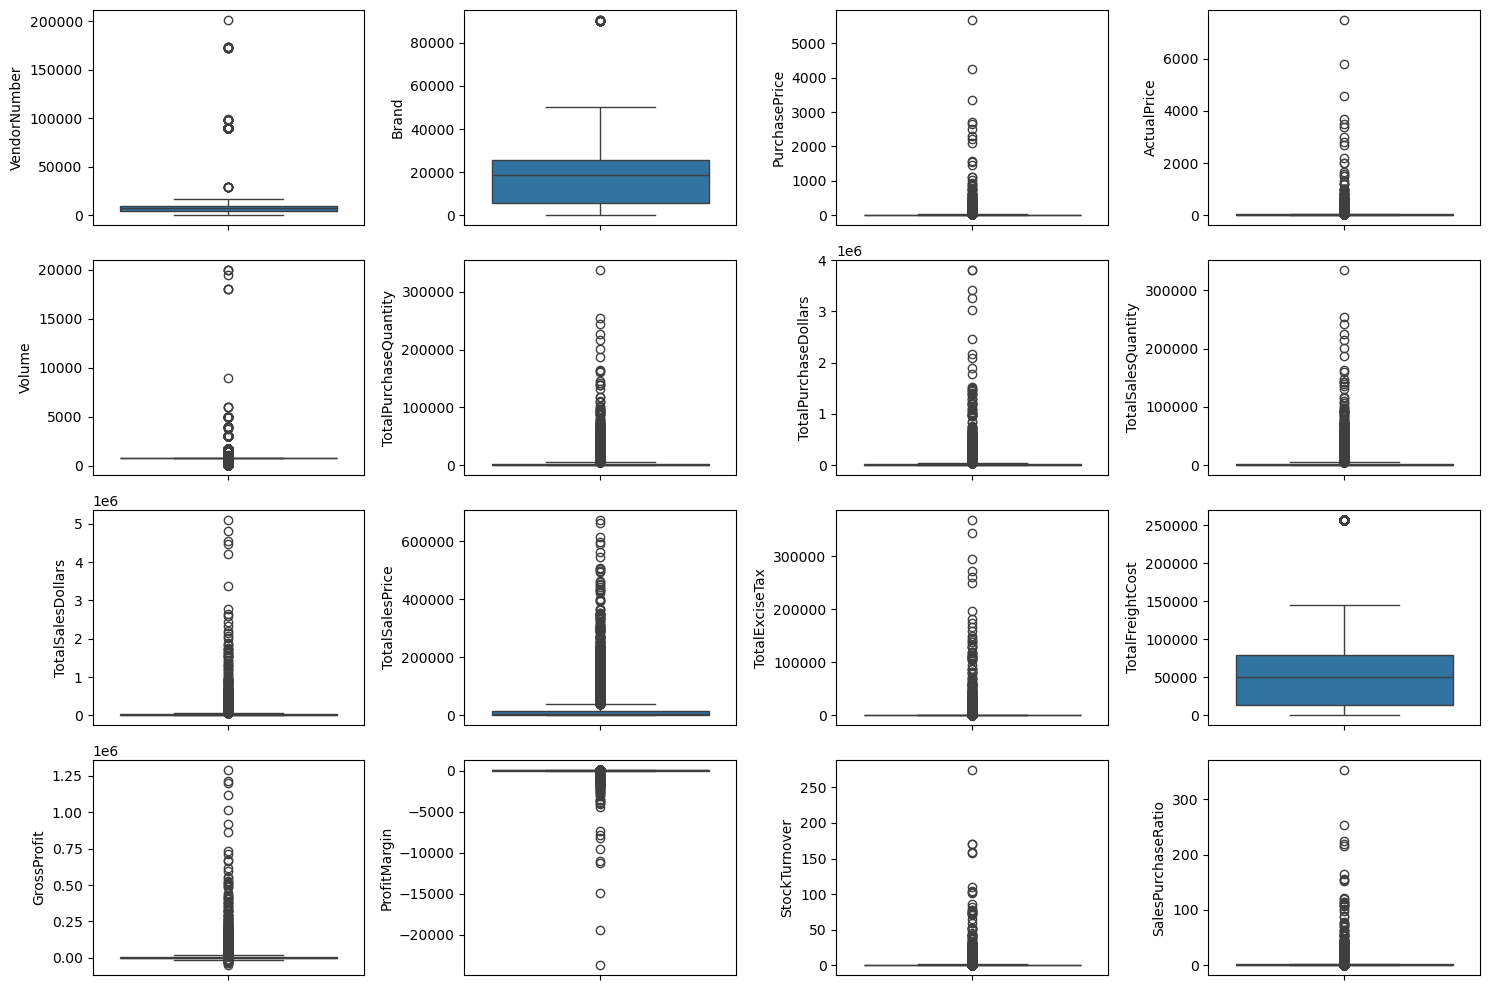

In [10]:
#Ditribution plots for numerical columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #adjust grid layout as needed
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()    

# Summary Statistics Insights:

**Negative and zero values:**

- **Gross Profit**:Mimnimum value is -52,002.78, indicating losses.Some products or transactions may be selling at a loss due to hibh cocts or selling at discounts lower than the purchase price.
- **Profit Mragin**:Has a minimum of (-infinity), Which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity and Sales Dollars**:Minimum value are 0, meaning some products were purchased bur=t never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by high Standard Deviations:**
- **Purchase and Actual Prices**: The max values (5,680.81 & 7,499.99) are significantly higher than the mean (24.39 and 35.64), indicating potential premium products.
- **Freight Cost**: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- **Stock Turnover**:Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.     

In [229]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""Select * 
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0""",conn)

In [12]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


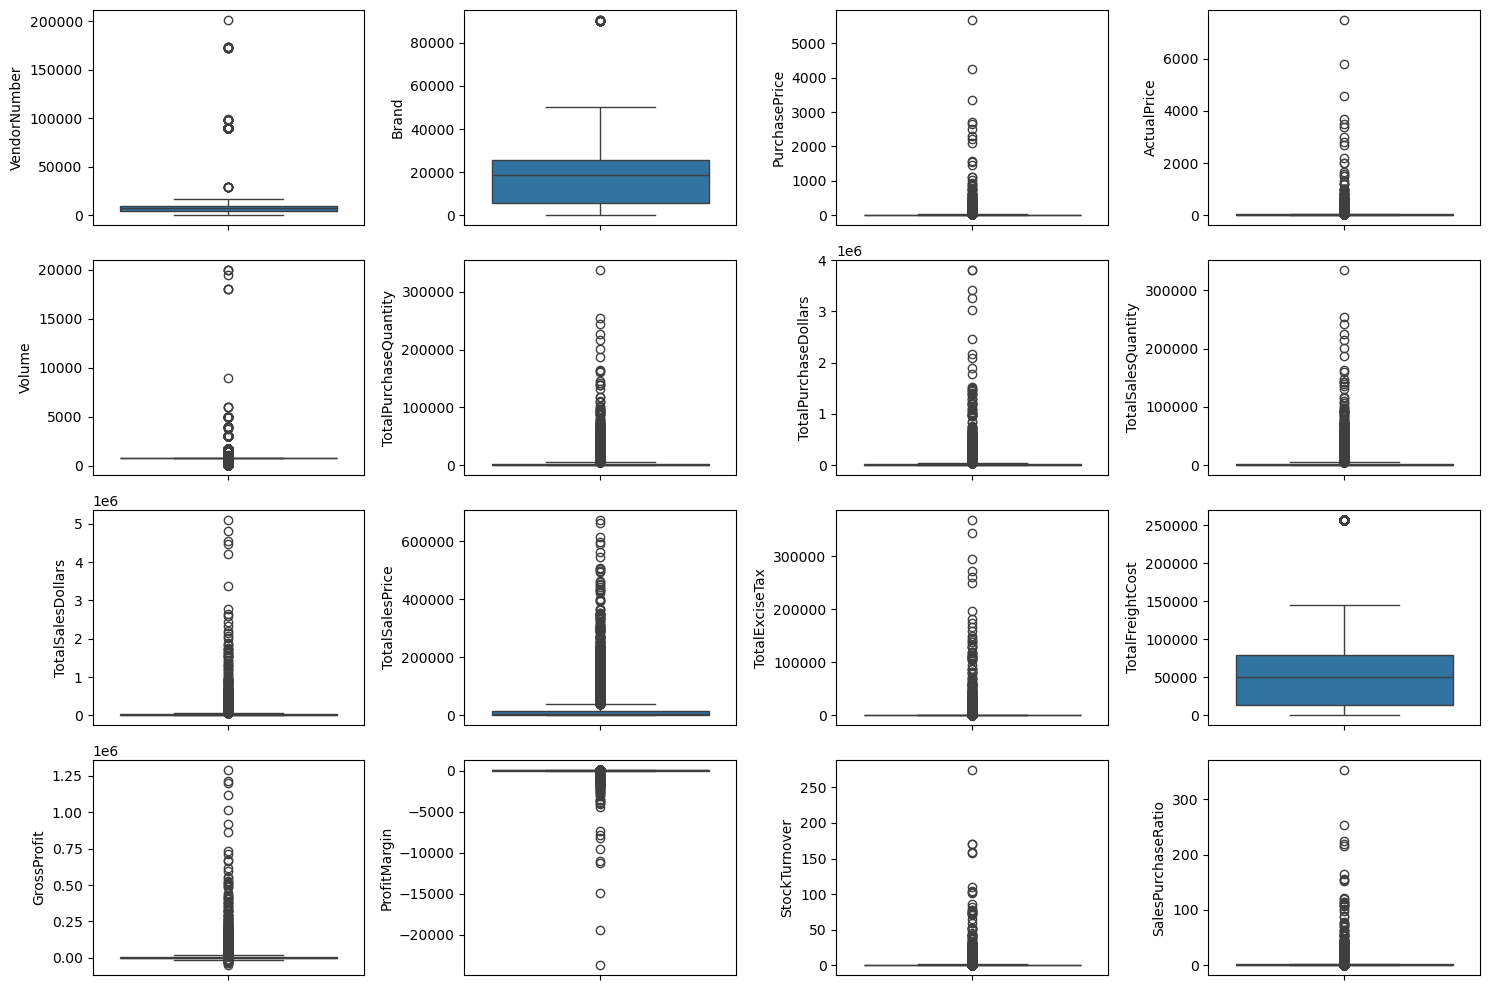

In [12]:
#Ditribution plots for numerical columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #adjust grid layout as needed
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()    

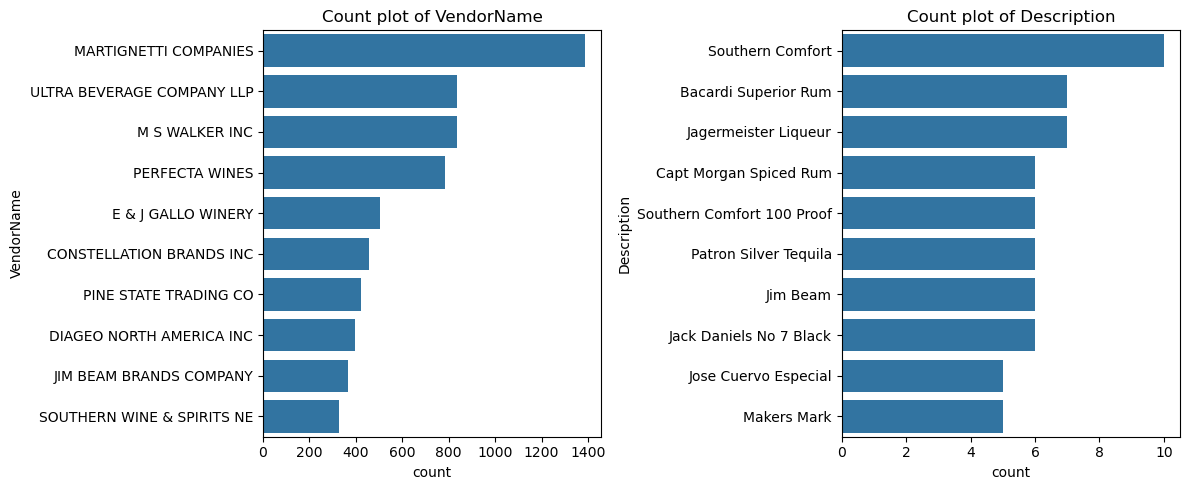

In [8]:
# Counts plots for categorical columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #Top 10 categories
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

In [9]:
# Correlation heat map to check correlation between numerical_cols
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

NameError: name 'numerical_cols' is not defined

<Figure size 1200x800 with 0 Axes>

# Correlation Insights

- **Purchase Price vs. Total Sales Dollars & Gross Profit**:PurchasePrice has weak correlation with TotalSalesDollars(-0.012) and GrossProfit(-0.016), suggesting that price variations do not significantly impact sales revenue or profit
- **Yotal Purchase Quantity vs. Total Sales Quantity**:Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- **Profit Margin vs. Total Sales Price**:Negative correlation between profit margin and total sales price(-0.179 suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- **Stock Turnover vs. Gross Profit & Profit Margin**:StockTurnover has weak negative correlation with both GrossProfit(-0.038) and ProfitMargin(-0.055), indicating that fater turnover does not necessarily result in higher profitability

# Data Analyis

**Q1.Identify Brands that needs promotional pr pricing adjustments which exhibit lower sales performance but higher profit margins.**


In [10]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean'}).reset_index()

In [51]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [67]:
# We have to give threshold values for both TotalSalesDollars(low sales) and ProfitMargin(High profit margin)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [68]:
low_sales_threshold

np.float64(560.299)

In [69]:
high_margin_threshold

np.float64(64.97017552750113)

In [70]:
# So we have to target those brands which are Low Sales<(560.299) and  Profit Margins>(64.97).
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [71]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #for better visualization in scatter plot 

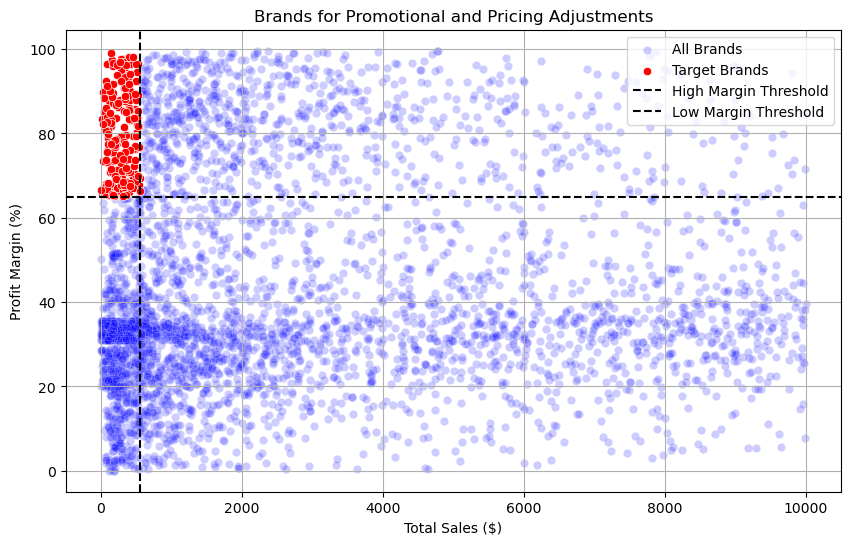

In [76]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='blue', label='All Brands', alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Margin Threshold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional and Pricing Adjustments")
plt.legend()
plt.grid()
plt.show()

**Q2.Which vendors and brands demonstrate the highest sales performance?.**

In [12]:
# Function for formating values
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}k"
    else:
        return str(value)

In [13]:
# Top Vendors and Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors.apply(lambda x :format_dollars(x) )

VendorName
DIAGEO NORTH AMERICA INC      68.74M
MARTIGNETTI COMPANIES         40.96M
PERNOD RICARD USA             32.28M
JIM BEAM BRANDS COMPANY       31.90M
BACARDI USA INC               25.01M
CONSTELLATION BRANDS INC      24.47M
E & J GALLO WINERY            18.55M
BROWN-FORMAN CORP             18.48M
ULTRA BEVERAGE COMPANY LLP    17.80M
M S WALKER INC                15.44M
Name: TotalSalesDollars, dtype: object

In [14]:
top_brands.apply(lambda x :format_dollars(x) )

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

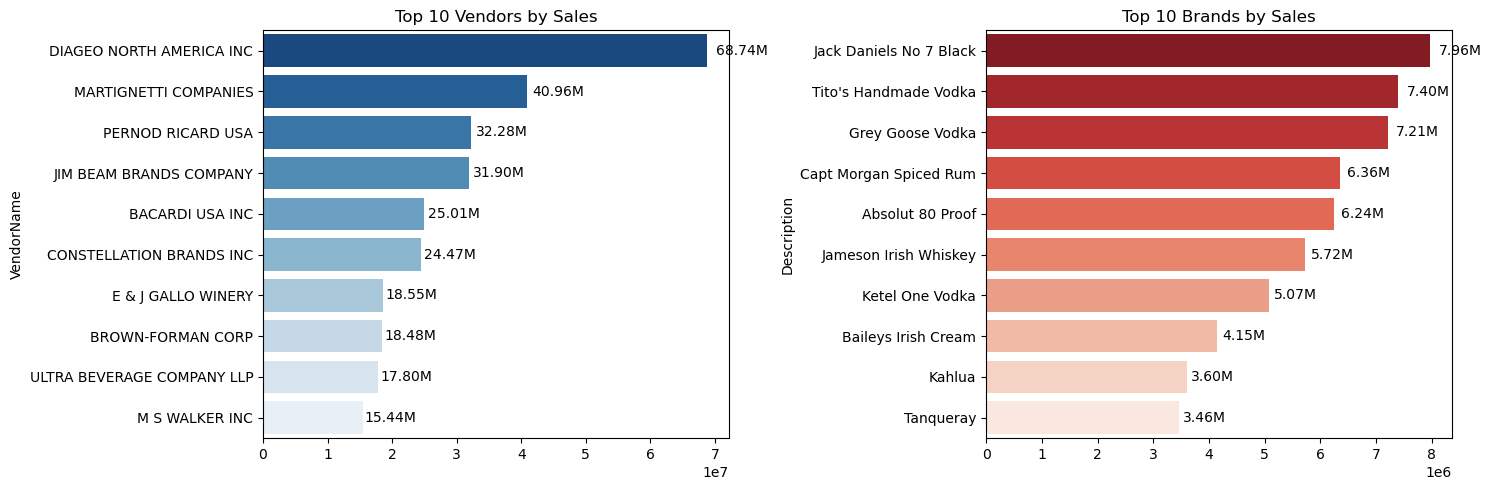

<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(15,5))

#Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")
for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()), ha='left',
             va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Q3.Which vendors contribute the most to total purchase dollars?**

In [104]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'TotalFreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesPurchaseRatio'],
      dtype='object')

In [159]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()

In [196]:
vendor_performance['Purchase_Contribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100 

In [197]:
vendor_performance=round(vendor_performance.sort_values('Purchase_Contribution%', ascending = False),2)

In [198]:
#Display Top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(lambda x: format_dollars(x))
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(lambda x: format_dollars(x))
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(lambda x: format_dollars(x))
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Purchase_Contribution%
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,0.16,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,0.09,8.66
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,0.08,7.52
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,0.07,7.49
8,BACARDI USA INC,17.62M,7.38M,25.01M,0.05,5.48
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,0.05,4.84
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,0.04,4.20
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,0.04,4.10
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,0.04,3.82
59,M S WALKER INC,10.94M,4.50M,15.44M,0.03,3.40


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Purchase_Contribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,0.16,15.83,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,0.09,8.66,24.49
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,0.08,7.52,32.01
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,0.07,7.49,39.50
8,BACARDI USA INC,17.62M,7.38M,25.01M,0.05,5.48,44.98
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,0.05,4.84,49.82
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,0.04,4.20,54.02
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,0.04,4.10,58.12
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,0.04,3.82,61.94
59,M S WALKER INC,10.94M,4.50M,15.44M,0.03,3.40,65.34


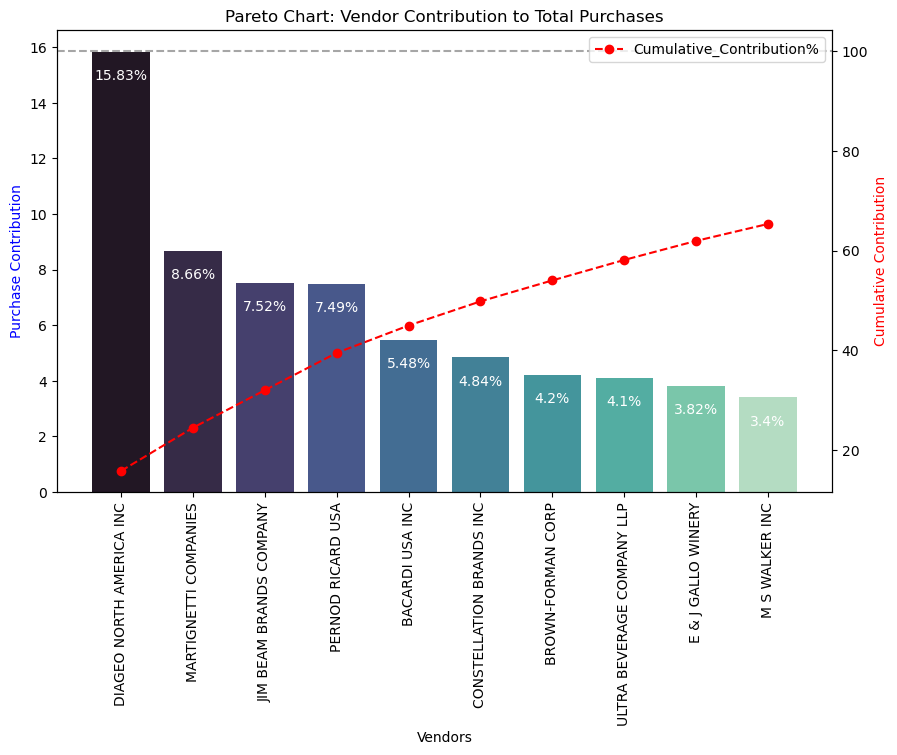

In [202]:
# Total Contribution of 10 vendors 
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum() #So contribution of top 10 vendors is 65% 

fig, ax1= plt.subplots(figsize=(10, 6))

#Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value -1, str(value)+'%', ha='center', fontsize=10, color='white')

#Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative_Contribution%')

ax1.set_xticklabels (top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution', color='blue')
ax2.set_ylabel('Cumulative Contribution', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend (loc='upper right')

plt.show()

**Q4.How much of total procurement is dependent on the top vendors?**

In [209]:
print(f"Total Purchase Contribution of top 10 vendors is {top_vendors['Purchase_Contribution%'].sum()}%")

Total Purchase Contribution of top 10 vendors is 65.34%


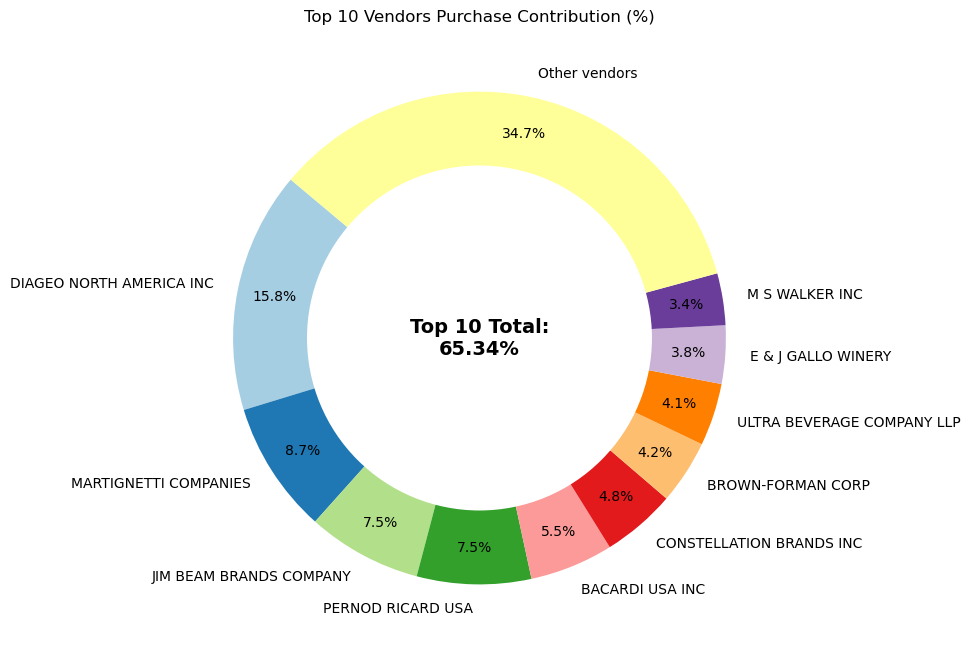

In [231]:
vendors = list(top_vendors['VendorName'].values)
purchased_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchased_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" Category
vendors.append("Other vendors")
purchased_contributions.append(remaining_contribution)

#Donut Chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchased_contributions, labels=vendors, autopct='%1.1f%%',
                                    startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Draw a white circle in the center to create donut effect
center_circle = plt.Circle((0,0),0.70, fc='white')
fig.gca().add_artist(center_circle)

#add total contribution annotation in the center 
plt.text(0,0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendors Purchase Contribution (%)")
plt.show()

**Q5.Does purchasing in bulk reduce the unit price, and what the optimal purchase volume for cost savings**

In [232]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [233]:
#Using qcut we create equal buckets for ordersize
df['OrderSize'] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=['Small','Medium','Large'])

In [234]:
df[['TotalPurchaseQuantity','OrderSize']]

,TotalPurchaseQuantity,OrderSize
0,145080,Large
1,164038,Large
2,187407,Large
3,201682,Large
4,138109,Large
...,...,...
8559,2,Small
8560,6,Small
8561,2,Small
8562,1,Small


In [236]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


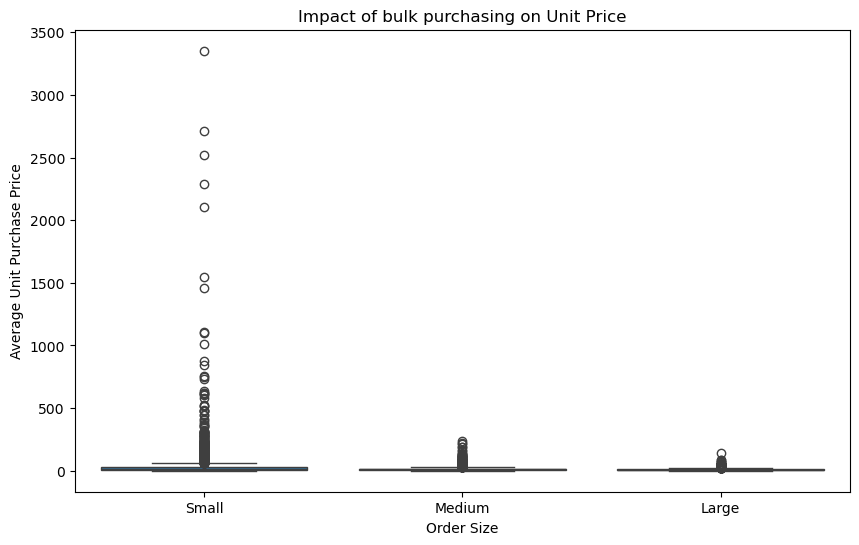

In [238]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice')
plt.title("Impact of bulk purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large order size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price between Small and Large order is substanial (-72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes,leading to higher overall sales despite lower per-unit revenue.

**Q6.Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**
It means those vendors who have more inventory but they can't sale properly

In [256]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**Q7.How much capital is locked in unsold inventory per vendor, and which vendors contibute the most to it?**

In [293]:
df["UnsoldInventoryValue"] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['PurchasePrice']
print('Total Unsold Capital:', format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 2.71M


In [298]:
# Aggregate Capital locked per Vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

#sort vendors with the highest locked per vendor
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue', ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


**Q8.What is the 95% confidence intervels for profit margins of top_performing and low_performing vendors.**

In [299]:
#So we are initializing some threshold values to calculate condfidence intervals
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [309]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= top_threshold]['ProfitMargin'].dropna()

In [311]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [312]:
#To calculate confidence interval we use this function
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) #Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.67, 41.81), Mean: 41.24


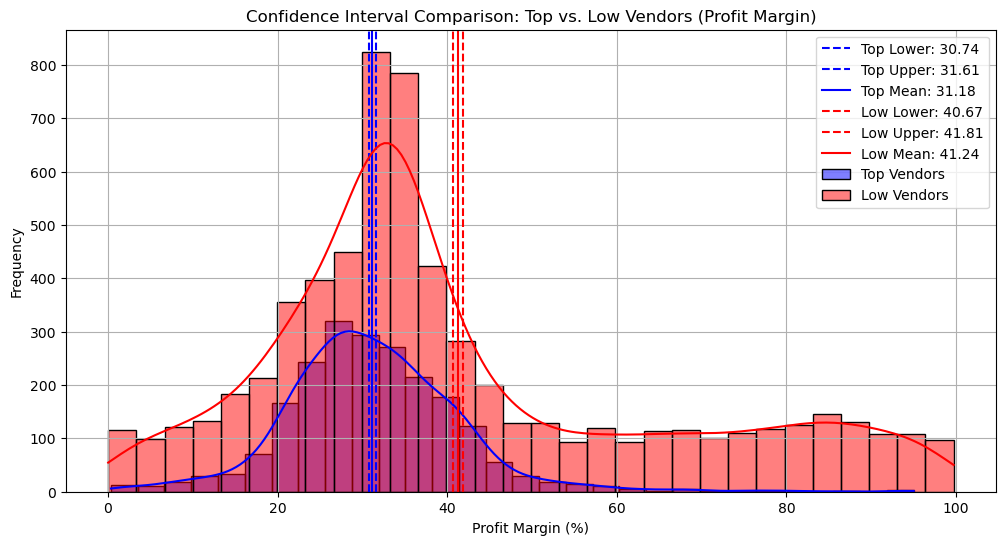

In [323]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

#Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low performance vendors(40.48% to 42.62%) is significantly higher than that of top performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational cost.
- For High-performance vendors: If they aim to improve profitibility, they could explore selective price adjustments, cost optimization, or bundling stratagies.
- For Low-performance vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

In [14]:
pd.dtype(df)

AttributeError: module 'pandas' has no attribute 'dtype'